# Imports

In [103]:
import numpy as np
import os
from joblib import Parallel, delayed
import re
from collections import defaultdict
from scipy.io import loadmat
import mne
import seaborn as sns
import pandas as pd
from scipy.stats import mode
import matplotlib.pyplot as plt
import sys

# get parent directory path to be able to import from parallel directory
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from hdf5_files.computing_features import psd_multitaper, wei_normalizing, index_W, index_N, index_R, Index_1, Index_2, Index_3, Index_4, calc_aperiodic_fit, calc_dfa, calc_mse
from hdf5_files.Artefacts_Detection import removeArtefacts, artefact_epochs

# Paths

In [104]:
mat_path = r"D:\dilon_data\MOTORWP4_dataset\sleep-edf_channel_test_mats"

# Variables

##### Old frequency bands

In [105]:
rodent_noise_band = [0,0.5]
rodent_delta_band = [0.5,5]
rodent_theta_band = [6,10]
rodent_sigma_band = [11,17]
rodent_gamma_band = [35,45]

##### New frequency bands

In [106]:
human_noise_band = [0,0.5]
human_delta_band = [0.5,3.99]
human_theta_band = [4,7.99]
human_sigma_band = [11,15]
human_gamma_band = [30,40]

### Theta frequency test

In [107]:
theta1_band = [4,5]
theta2_band = [5,6]
theta3_band = [6,7]
theta4_band = [7,8]

##### General

In [108]:
# epochs in seconds
epoch_length = 10

# Main

## Functions

##### Find data files

In [109]:
def initiate_files(input_path, subject):
    for file in os.listdir(input_path):
        if subject in file:
            if "Delta" in file:
                delta_f = os.path.join(input_path, file)
            if "Theta" in file:
                theta_f = os.path.join(input_path, file)
            if "states" in file:
                states_f = os.path.join(input_path, file)

    return [delta_f, theta_f, states_f]

##### Load data

In [110]:
def load_data(file_list, fs):
    delta_data = loadmat(file_list[0])
    delta_data = next(v for k, v in delta_data.items() if 'Delta' in k)
    #raw_delta = np.ravel(delta_data)
    print(len(delta_data))

    theta_data = loadmat(file_list[1])
    theta_data = next(v for k, v in theta_data.items() if 'Theta' in k)
    #raw_theta = np.ravel(theta_data)

    sleep_scoring = loadmat(file_list[2])
    states = sleep_scoring['states']
    try:
        states = states[0]
    except error as e:
        states = states

    sleep_scoring = np.ravel(states)
    sleep_scoring = np.array(sleep_scoring, dtype=int)
    reshaped_scores = sleep_scoring[:len(sleep_scoring) // (epoch_length*fs) * (epoch_length*fs)].reshape(-1, epoch_length*fs)
    states = mode(reshaped_scores, axis=1).mode.flatten()

    #return [raw_delta, raw_theta, states]
    return [delta_data, theta_data, states]

## Workflow

### Find unique subjects

In [111]:
subject_list = []

for file in os.listdir(mat_path):
    print(file)
    subject = '_'.join(file.split('_')[:2])
    if subject not in subject_list:
        subject_list.append(subject)

S40_2_Fpz-Cz_Noise_Delta_Beta_Gamma.mat
S40_2_Pz-Oz_Theta_Sigma.mat
S35_1_Fpz-Cz_Noise_Beta_Gamma.mat
S35_1_Pz-Oz_Delta_Theta_Sigma.mat
S35_2_Fpz-Cz_Noise_Beta_Gamma.mat
S35_2_Pz-Oz_Delta_Theta_Sigma.mat
S41_1_Fpz-Cz_Noise_Beta_Gamma.mat
S41_1_Pz-Oz_Delta_Theta_Sigma.mat
S41_2_Fpz-Cz_Noise_Beta_Gamma.mat
S41_2_Pz-Oz_Delta_Theta_Sigma.mat
S90_2_Fpz-Cz_Noise_Delta_Sigma_Beta_Gamma.mat
S90_2_Pz-Oz_Theta.mat
S42_1_Fpz-Cz_Noise_Beta.mat
S42_1_Pz-Oz_Delta_Theta_Sigma_Gamma.mat
S42_2_Fpz-Cz_Noise_Beta.mat
S42_2_Pz-Oz_Delta_Theta_Sigma_Gamma.mat
S36_1_Fpz-Cz_Noise_Delta.mat
S36_1_Pz-Oz_Theta_Sigma_Beta_Gamma.mat
S36_2_Fpz-Cz_Noise_Delta_Beta_Gamma.mat
S36_2_Pz-Oz_Theta_Sigma.mat
S89_2_Pz-Oz_Noise_Theta_Sigma_Beta_Gamma.mat
S89_2_Fpz-Cz_Delta.mat
S43_1_Pz-Oz_Noise_Theta_Sigma_Beta_Gamma.mat
S43_1_Fpz-Cz_Delta.mat
S43_2_Pz-Oz_Noise_Theta_Sigma_Beta_Gamma.mat
S43_2_Fpz-Cz_Delta.mat
S91_1_Pz-Oz_Noise_Theta_Sigma.mat
S91_1_Fpz-Cz_Delta_Beta_Gamma.mat
S91_2_Fpz-Cz_Noise_Delta_Beta_Gamma.mat
S91_2_Pz

In [112]:
print(subject_list)

['S40_2', 'S35_1', 'S35_2', 'S41_1', 'S41_2', 'S90_2', 'S42_1', 'S42_2', 'S36_1', 'S36_2', 'S89_2', 'S43_1', 'S43_2', 'S91_1', 'S91_2', 'S78_1', 'S78_2', 'S44_1', 'S44_2', 'S92_1', 'S92_2', 'S37_1', 'S37_2', 'S77_1', 'S77_2', 'S93_1', 'S93_2', 'S38_1', 'S38_2', 'S79_1', 'S79_2', 'S94_1', 'S94_2', 'S39_1', 'S39_2', 'S71_1', 'S71_2', 'S95_1', 'S95_2', 'S80_1', 'S80_2', 'S96_1', 'S96_2', 'S60_1', 'S60_2', 'S97_1', 'S97_2', 'S81_1', 'S81_2', 'S98_1', 'S98_2', 'S72_1', 'S72_2', 'S99_1', 'S99_2', 'S82_1', 'S82_2', 'S56_1', 'S56_2', 'S83_1', 'S83_2', 'S73_1', 'S73_2', 'S84_1', 'S84_2', 'S61_1', 'S61_2', 'S85_1', 'S85_2', 'S74_1', 'S74_2', 'S86_1', 'S86_2', 'S55_1', 'S55_2', 'S87_1', 'S87_2', 'S75_1', 'S75_2', 'S88_2', 'S62_1', 'S62_2', 'S76_1', 'S76_2', 'S57_1', 'S57_2', 'S54_1', 'S54_2', 'S63_1', 'S58_1', 'S58_2', 'S64_1', 'S64_2', 'S53_1', 'S53_2', 'S59_1', 'S59_2', 'S45_1', 'S45_2', 'S46_1', 'S46_2', 'S47_2', 'S48_1', 'S48_2', 'S49_1', 'S49_2', 'S50_1', 'S50_2', 'S51_1', 'S51_2', 'S52_1', 

### Iterate subjects

In [ ]:
rodent_average_psd = {}
human_average_psd = {}

r_average_psd_per_subject = defaultdict(dict)
h_average_psd_per_subject = defaultdict(dict)


for subject in subject_list:
    if 'SC' in subject or 'ST' in subject:
        fs = 100
    else: 
        fs = 250
    print(subject)
    print(fs)
    files_list = initiate_files(mat_path, subject)
    data_list = load_data(files_list, fs)

    window_length = epoch_length * fs

    delta_sig = removeArtefacts(data_list[0], fs, [9,8], [0.2, 0.1])
    theta_sig = removeArtefacts(data_list[1], fs, [9,8], [0.2, 0.1])
    delta_filt = np.ravel(delta_sig[0])
    theta_filt = np.ravel(theta_sig[0])

    # r_fr_bands = [rodent_delta_band, rodent_theta_band]
    # h_fr_bands = [human_delta_band, human_theta_band]

    #r_delta, r_theta = Parallel(n_jobs=2)(delayed(psd_multitaper)(raw, fs, band, window_length) for raw, band in zip(data_list[:-1], r_fr_bands))
    r_delta = psd_multitaper(np.ravel(delta_filt), fs, rodent_delta_band, window_length)
    r_theta = psd_multitaper(np.ravel(delta_filt), fs, rodent_theta_band, window_length)
  
    #h_delta, h_theta = Parallel(n_jobs=2)(delayed(psd_multitaper)(raw, fs, band, window_length) for raw, band in zip(data_list[:-1], h_fr_bands))
    h_delta = psd_multitaper(np.ravel(delta_filt), fs, human_delta_band, window_length)
    h_theta = psd_multitaper(np.ravel(theta_filt), fs, human_theta_band, window_length)

    # Normalize all these powers rodent
    r_delta_norm = wei_normalizing(r_delta)
    r_theta_norm = wei_normalizing(r_theta)
    # Normalize all these powers human
    h_delta_norm = wei_normalizing(h_delta)
    h_theta_norm = wei_normalizing(h_theta)

    # Get smoothed powers as feature rodent
    r_theta_smoothed = np.convolve(np.convolve(np.convolve(r_theta_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
    r_delta_smoothed = np.convolve(np.convolve(np.convolve(r_delta_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
    # Get smoothed powers as feature human
    h_theta_smoothed = np.convolve(np.convolve(np.convolve(h_theta_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
    h_delta_smoothed = np.convolve(np.convolve(np.convolve(h_delta_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')

    print(h_theta_smoothed)
    print(h_delta_smoothed)

    # get average per state
    r_psd_per_subject = defaultdict(list)
    h_psd_per_subject = defaultdict(list)

    for i in range(len(r_theta_smoothed)):
        r_psd_per_subject[data_list[2][i]].append([r_delta_smoothed[i], r_theta_smoothed[i]])
        h_psd_per_subject[data_list[2][i]].append([h_delta_smoothed[i], h_theta_smoothed[i]])

    for state in r_psd_per_subject.keys():
        r_state_mean = np.nanmean(r_psd_per_subject[state], axis=0)
        h_state_mean = np.nanmean(h_psd_per_subject[state], axis=0)
        r_average_psd_per_subject[subject][state] = r_state_mean
        h_average_psd_per_subject[subject][state] = h_state_mean


S40_2
250
7717593
[0.21062526 0.30285209 0.38739904 ... 0.34614543 0.2928694  0.22507776]
[0.08439232 0.11860624 0.14689662 ... 0.50182347 0.36213457 0.23258573]
S35_1
250
7290094
[0.08744903 0.13209887 0.17369371 ... 0.23038789 0.17519511 0.1163376 ]
[0.05580761 0.0768829  0.09521855 ... 0.35654538 0.28184143 0.19493505]
S35_2
250
6922579
[0.03007674 0.04958771 0.07286243 ... 0.41753124 0.34931326 0.2638343 ]
[0.05900293 0.09744254 0.13955958 ... 0.36813905 0.31617167 0.2436206 ]
S41_1
250
7582689
[0.09567619 0.14950725 0.20274956 ... 0.61317202 0.47594228 0.32887939]
[0.22756445 0.34651056 0.46569887 ... 0.69220105 0.54039181 0.37647473]
S41_2
250
7762645
[0.04609339 0.06680263 0.08845735 ... 0.09907322 0.08355059 0.06380513]
[0.21232972 0.27921679 0.3280912  ... 0.16360101 0.14192137 0.11103823]
S90_2
250
7717578
[0.16885284 0.24213964 0.30408714 ... 0.27433075 0.2122727  0.14810255]
[0.2889863  0.38381954 0.45699128 ... 0.67626058 0.51107499 0.34974163]
S42_1
250
8062582
[0.0926073

In [ ]:
# theta_average_psd = {}

# theta_average_psd_per_subject = defaultdict(dict)


# for subject in subject_list:
#     if 'SC' in subject or 'ST' in subject:
#         fs = 100
#     else: 
#         fs = 250
#     print(subject)

#     files_list = initiate_files(mat_path, subject)
#     data_list = load_data(files_list, fs)

#     window_length = epoch_length * fs

#     theta_fr_bands = [theta1_band, theta2_band, theta3_band, theta4_band]

#     theta1, theta2, theta3, theta4 = Parallel(n_jobs=6)(delayed(psd_multitaper)(raw, fs, band, window_length) for raw, band in zip(data_list[:-1], theta_fr_bands))
    
#     # Normalize all these powers rodent
#     theta1_norm = wei_normalizing(theta1)
#     theta2_norm = wei_normalizing(theta2)
#     theta3_norm = wei_normalizing(theta3)
#     theta4_norm = wei_normalizing(theta4)

#     # Get smoothed powers as feature rodent
#     theta1_smoothed = np.convolve(np.convolve(np.convolve(theta1_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
#     theta2_smoothed = np.convolve(np.convolve(np.convolve(theta2_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
#     theta3_smoothed = np.convolve(np.convolve(np.convolve(theta3_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
#     theta4_smoothed = np.convolve(np.convolve(np.convolve(theta4_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')

#     # get average per state
#     theta_psd_per_subject = defaultdict(list)

#     for i in range(len(theta1_smoothed)):
#         theta_psd_per_subject[data_list[6][i]].append([theta1_smoothed[i], theta2_smoothed[i], theta3_smoothed[i], theta4_smoothed[i]])

#     for state in theta_psd_per_subject.keys():
#         theta_state_mean = np.mean(theta_psd_per_subject[state], axis=0)
#         theta_average_psd_per_subject[subject][state] = theta_state_mean


##### Find data files

In [1]:
print(h_average_psd_per_subject)

NameError: name 'h_average_psd_per_subject' is not defined

In [ ]:
rows = []
feature_names = ['delta', 'theta']
#feature_names = ["Theta (4-5)", "Theta (5-6)", "Theta (6-7)", "Theta (7-8)"]

for subject, state_dict in r_average_psd_per_subject.items():
    # if "ST" not in subject and "SC" not in subject:
    for state, features in state_dict.items():
        if state in [0,1,2,3,4]:
            for i, value in enumerate(features):
                rows.append({
                    "Subject": subject,
                    "State": state,
                    "FeatureIndex": i,
                    "Feature": feature_names[i],
                    "Value": value
                })

r_df = pd.DataFrame(rows)

rows = []

for subject, state_dict in h_average_psd_per_subject.items():
    # if "ST" not in subject and "SC" not in subject:
    for state, features in state_dict.items():
        if state in [0,1,2,3,4]:
            for i, value in enumerate(features):
                rows.append({
                    "Subject": subject,
                    "State": state,
                    "FeatureIndex": i,
                    "Feature": feature_names[i],
                    "Value": value
                })

h_df = pd.DataFrame(rows)

In [ ]:
def features_violin(rdf, hdf, feature_name, state_id, state_names, colors):
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14, 5))
    #plt.figure(figsize=(7,5))
    
    # rodent plot
    sns.violinplot(x='State', y='Value', data=rdf, palette=colors, alpha=0.6, zorder=2, ax=ax1)
    sns.stripplot(x='State', y='Value', data=rdf, color='black', alpha=0.5, zorder=1, marker='D', size=4, jitter=0.25, ax=ax1)
    ax1.set_title(f"Distribution of {feature_name} per state - Rodent frequency bands")
    ax1.set_ylabel(f"Normalized {feature_name} value")
    ax1.set_xticks(state_id, state_names)
    ax1.set_ylim(0,1)
    ax1.grid(axis='y', color='lightgray', linestyle='--', alpha=0.6, zorder=0)

    # human plot
    sns.violinplot(x='State', y='Value', data=hdf, palette=colors, alpha=0.6, zorder=2, ax=ax2)
    sns.stripplot(x='State', y='Value', data=hdf, color='black', alpha=0.5, zorder=1, marker='D', size=4, jitter=0.25, ax=ax2)
    ax2.set_title(f"Distribution of {feature_name} per state - Human frequency bands")
    ax2.set_ylabel(f"Normalized {feature_name} value")
    ax2.set_xticks(state_id, state_names)
    ax2.set_ylim(0,1)
    ax2.grid(axis='y', color='lightgray', linestyle='--', alpha=0.6, zorder=0)

    plt.savefig(os.path.join(r"D:\dilon_data\visualization_collection\rodent-vs-human_freqband_comparison", f'motorwp4_fpz-pz_{feature_name}_comparison.svg'), format="svg")

    plt.tight_layout()
    plt.show()

In [ ]:
# def features_violin(rdf, hdf, feature_name, state_id, state_names, colors):
#     # fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14, 5))
#     plt.figure(figsize=(7,5))
    
#     # rodent plot
#     sns.violinplot(x='State', y='Value', data=rdf, palette=colors, alpha=0.6, zorder=2)
#     sns.stripplot(x='State', y='Value', data=rdf, color='black', alpha=0.5, zorder=1, marker='D', size=4, jitter=0.25)
#     plt.title(f"Distribution of {feature_name} per state - Rodent frequency bands")
#     plt.ylabel(f"Normalized {feature_name} value")
#     plt.xticks(state_id, state_names)
#     plt.ylim(0,1)
#     plt.grid(axis='y', color='lightgray', linestyle='--', alpha=0.6, zorder=0)
#     plt.savefig(os.path.join(r"D:\dilon_data\visualization_collection\theta_comparison", f'split_theta_{feature_name}_comparison.svg'), format="svg")

#     plt.tight_layout()
#     plt.show()

In [ ]:
state_names = ['Wake', 'N1', 'N2', 'N3', 'REM']
colors = ['royalblue', 'teal', 'purple', 'forestgreen', 'firebrick']

C:\Users\andri\AppData\Local\Temp\ipykernel_20016\1518637808.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='State', y='Value', data=rdf, palette=colors, alpha=0.6, zorder=2, ax=ax1)
C:\Users\andri\AppData\Local\Temp\ipykernel_20016\1518637808.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='State', y='Value', data=hdf, palette=colors, alpha=0.6, zorder=2, ax=ax2)


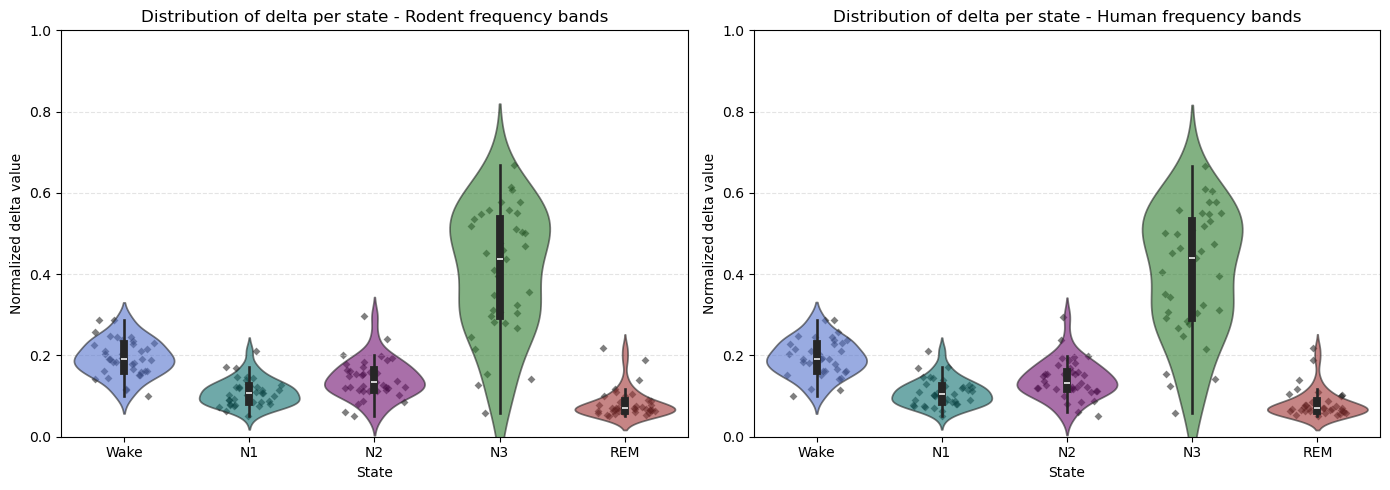

C:\Users\andri\AppData\Local\Temp\ipykernel_20016\1518637808.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='State', y='Value', data=rdf, palette=colors, alpha=0.6, zorder=2, ax=ax1)
C:\Users\andri\AppData\Local\Temp\ipykernel_20016\1518637808.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='State', y='Value', data=hdf, palette=colors, alpha=0.6, zorder=2, ax=ax2)


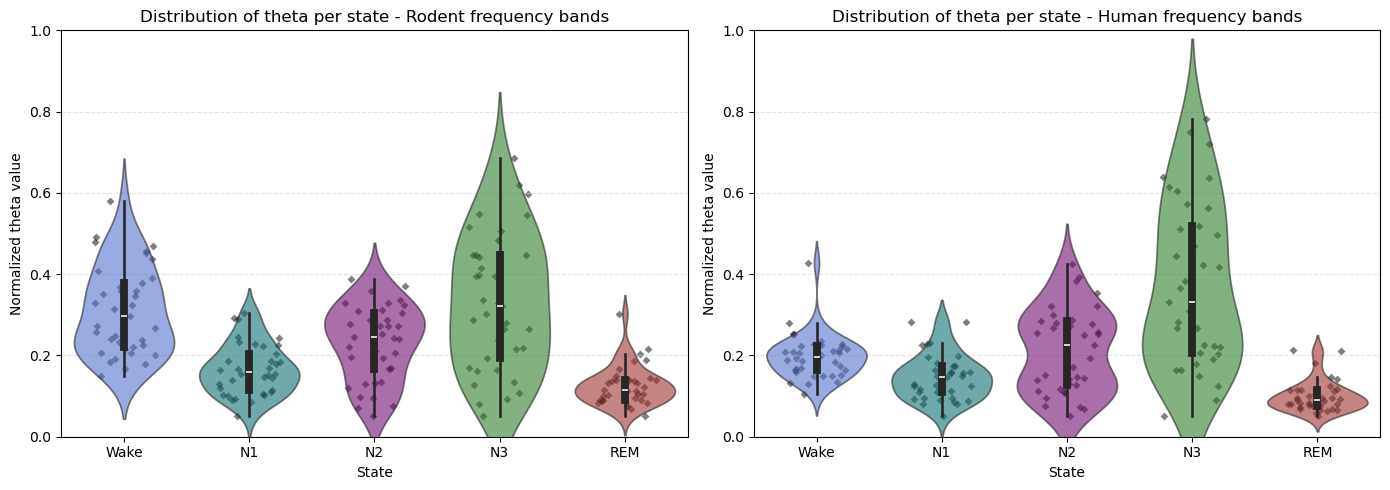

In [ ]:
for f_name in feature_names:
    r_df_feat = r_df[r_df['Feature'] == f_name]
    h_df_feat = h_df[h_df['Feature'] == f_name]
    features_violin(r_df_feat, h_df_feat, f_name, [0,1,2,3,4], state_names, colors)